# It's a flow of tensors

If you have already built a model, you can use the model.layers and the tensorflow.keras.backend to build functions that, provided with a valid input tensor, return the corresponding output tensor.

This is a useful tool when we want to obtain the output of a network at an intermediate layer.

For instance, if you get the input and output from the first layer of a network, you can build an inp_to_out function that returns the result of carrying out forward propagation through only the first layer for a given input tensor.

In [1]:
import pandas as pd
banknotes = pd.read_csv("dataset/banknotes.csv")
banknotes.head()

,variace,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [2]:
# Import the sequential model and dense layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create a sequential model
model = Sequential()

# Add a dense layer 
model.add(Dense(2, input_shape=(4,), activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

# Compile your model
model.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])

# Display a summary of your model
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 2)                 10        
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 3         
Total params: 13
Trainable params: 13
Non-trainable params: 0
_________________________________________________________________


In [3]:
from sklearn.model_selection import train_test_split
X= banknotes.drop('class', axis=1)
y= banknotes['class']
from tensorflow.keras.utils import to_categorical
# y = to_categorical(banknotes['class']) 
# using the train test split function
X_train, X_test, y_train, y_test = train_test_split( X,y , random_state=104,test_size=0.25, shuffle=True)

In [4]:
import tensorflow.keras.backend as K

# Assuming model is defined and X_test is your test data
# Assuming X_test is a numpy array containing your test data
# Assuming model is already compiled and ready for use

# Input tensor from the 1st layer of the model
inp = model.layers[0].input

# Output tensor from the 1st layer of the model
out = model.layers[0].output

# Define a function from inputs to outputs
inp_to_out = K.function([inp], [out])

# Assuming X_test is a numpy array containing your test data
# Print the results of passing X_test through the 1st layer
# Replace X_test with your actual test data
print(inp_to_out([X_test.values]))


[array([[5.43543398e-02, 4.11353618e-01],
       [7.61529803e-03, 3.66411805e-02],
       [8.93802881e-01, 7.14149594e-01],
       [9.67660308e-01, 3.67201388e-01],
       [9.99996185e-01, 9.83141065e-01],
       [4.85062046e-05, 1.26744509e-02],
       [1.53142214e-03, 3.19212079e-02],
       [9.85812187e-01, 5.54571986e-01],
       [3.05189872e-07, 1.16716874e-04],
       [9.95468497e-01, 4.49392676e-01],
       [9.92748797e-01, 7.74101138e-01],
       [9.90434170e-01, 4.70658302e-01],
       [2.43335962e-04, 2.06789374e-02],
       [5.18530607e-04, 1.58904493e-02],
       [1.98774342e-06, 3.28063965e-04],
       [8.49393010e-03, 1.57037854e-01],
       [9.99994636e-01, 8.67643416e-01],
       [6.38931990e-04, 4.04800475e-02],
       [3.18619430e-01, 1.94125533e-01],
       [1.90344453e-03, 3.06766927e-02],
       [7.48544931e-04, 2.41123736e-02],
       [2.12013721e-04, 1.75102949e-02],
       [3.90598178e-03, 4.74505424e-02],
       [2.53929496e-02, 9.85790491e-02],
       [9.96170

# Neural separation

Neurons learn by updating their weights to output values that help them better distinguish between the different output classes in your dataset. You will make use of the inp_to_out() function you just built to visualize the output of two neurons in the first layer of the Banknote Authentication model as it learns.

In [5]:
import matplotlib.pyplot as plt
def plot():
  fig, ax = plt.subplots()
  plt.scatter(layer_output[:, 0], layer_output[:, 1],c = y_test,edgecolors='none')
  plt.title('Epoch: {}, Test Accuracy: {:3.1f} %'.format(i+1, test_accuracy * 100.0))
  plt.show()

11/11 [==============================] - 0s 1ms/step - loss: 0.6541 - accuracy: 0.7580


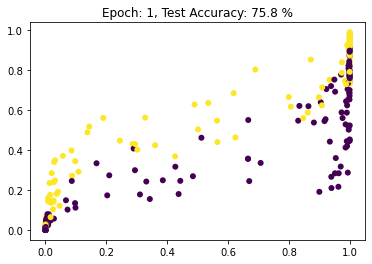

11/11 [==============================] - 0s 725us/step - loss: 0.5978 - accuracy: 0.9038


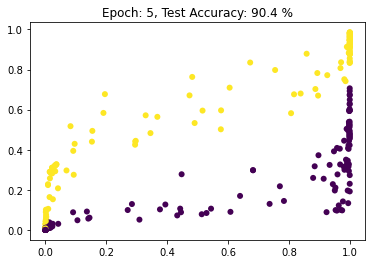

11/11 [==============================] - 0s 541us/step - loss: 0.5445 - accuracy: 0.9184


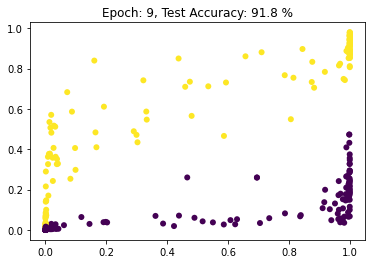

11/11 [==============================] - 0s 726us/step - loss: 0.4968 - accuracy: 0.9388


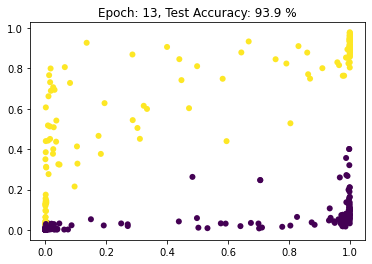

11/11 [==============================] - 0s 1ms/step - loss: 0.4448 - accuracy: 0.9738


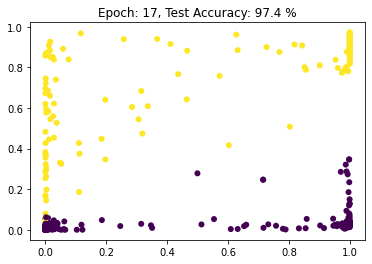

11/11 [==============================] - 0s 632us/step - loss: 0.4009 - accuracy: 0.9708


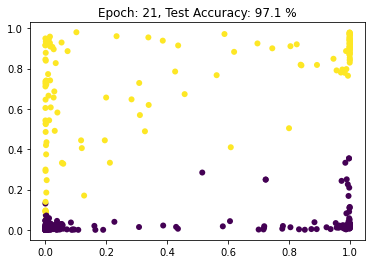

In [6]:
for i in range(0, 21):
  	# Train model for 1 epoch
    h = model.fit(X_train, y_train, batch_size = 16, epochs = 1, verbose = 0)
    if i%4==0: 
      # Get the output of the first layer
      layer_output = inp_to_out([X_test.values])[0]
      
      # Evaluate model accuracy for this epoch
      test_accuracy = model.evaluate(X_test, y_test)[1] 
      
      # Plot 1st vs 2nd neuron output
      plot()

# Building an autoencoder

Autoencoders have several interesting applications like anomaly detection or image denoising. They aim at producing an output identical to its inputs. The input will be compressed into a lower dimensional space, encoded. The model then learns to decode it back to its original form.

You will encode and decode the MNIST dataset of handwritten digits, the hidden layer will encode a 32-dimensional representation of the image, which originally consists of 784 pixels (28 x 28). The autoencoder will essentially learn to turn the 784 pixels original image into a compressed 32 pixels image and learn how to use that encoded representation to bring back the original 784 pixels image.

In [7]:
import pandas as pd
import numpy as np
# df = pd.read_csv("dataset/")
X = np.load("dataset/digits_pixels.npy")
y = np.load("dataset/digits_target.npy")
from tensorflow.keras.utils import to_categorical
y = y.reshape(-1,1)
y = to_categorical(y)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X,y , random_state=104,test_size=0.3, shuffle=True)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(1257, 64)
(1257, 10)
(540, 64)
(540, 10)


In [8]:
# # Start with a sequential model
# autoencoder = Sequential()

# # Add a dense layer with input the original image pixels and neurons the encoded representation
# autoencoder.add(Dense(32, input_shape=(784, ), activation="relu"))

# # Add an output layer with as many neurons as the orginal image pixels
# autoencoder.add(Dense(784, activation = "sigmoid"))

# # Compile your model with adadelta
# autoencoder.compile(optimizer = 'adadelta', loss = 'binary_crossentropy')

# # Summarize your model structure
# autoencoder.summary()

In [9]:
# Start with a sequential model
autoencoder = Sequential()

# Add a dense layer with input the original image pixels and neurons the encoded representation
autoencoder.add(Dense(10, input_shape=(64, ), activation="relu"))

# Add an output layer with as many neurons as the orginal image pixels
autoencoder.add(Dense(64, activation = "sigmoid"))

# Compile your model with adadelta
autoencoder.compile(optimizer = 'adadelta', loss = 'binary_crossentropy')

# Summarize your model structure
autoencoder.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_2 (Dense)              (None, 10)                650       
_________________________________________________________________
dense_3 (Dense)              (None, 64)                704       
Total params: 1,354
Trainable params: 1,354
Non-trainable params: 0
_________________________________________________________________


# De-noising like an autoencoder

Okay, you have just built an autoencoder model. Let's see how it handles a more challenging task.

First, you will build a model that encodes images, and you will check how different digits are represented with show_encodings(). To build the encoder you will make use of your autoencoder, that has already being trained. You will just use the first half of the network, which contains the input and the bottleneck output. That way, you will obtain a 32 number output which represents the encoded version of the input image.

Then, you will apply your autoencoder to noisy images from MNIST, it should be able to clean the noisy artifacts.

In [10]:
def show_encodings(encoded_imgs,number=1):
    n = 5  # how many digits we will display
    original = X_test
    original = original[np.where(y_test == number)]
    encoded_imgs = encoded_imgs[np.where(y_test==number)]
    plt.figure(figsize=(20, 4))
    #plt.title('Original '+str(number)+' vs Encoded representation')
    for i in range(min(n,len(original))):
        # display original imgs
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # display encoded imgs
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(np.tile(encoded_imgs[i],(32,1)))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.show()

In [11]:
def compare_plot(original,decoded_imgs):
    n = 4  # How many digits we will display
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Display original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Display reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.title('Noisy vs Decoded images')
    plt.show()

In [12]:
# # Build your encoder by using the first layer of your autoencoder
# encoder = Sequential()
# encoder.add(autoencoder.layers[0])

# # Encode the noisy images and show the encodings for your favorite number [0-9]
# encodings = encoder.predict(X_test)
# show_encodings(encodings, number = 1)

In [13]:
# # Build your encoder by using the first layer of your autoencoder
# encoder = Sequential()
# encoder.add(autoencoder.layers[0])

# # Encode the noisy images and show the encodings for your favorite number [0-9]
# encodings = encoder.predict(X_test_noise)
# show_encodings(encodings, number = 1)

# # Predict on the noisy images with your autoencoder
# decoded_imgs = autoencoder.predict(X_test_noise)

# # Plot noisy vs decoded images
# compare_plot(X_test_noise, decoded_imgs)

# Building a CNN model

Building a CNN model in Keras isn't much more difficult than building any of the models you've already built throughout the course! You just need to make use of convolutional layers.

You're going to build a shallow convolutional model that classifies the MNIST digits dataset. The same one you de-noised with your autoencoder! The images are 28 x 28 pixels and just have one channel, since they are black and white pictures.

In [14]:
# Import the Conv2D and Flatten layers and instantiate model
from tensorflow.keras.layers import Conv2D,Flatten
model = Sequential()

# Add a convolutional layer of 32 filters of size 3x3
model.add(Conv2D(filters=32, kernel_size = 3, input_shape = (28, 28, 1), activation = 'relu'))

# Add a convolutional layer of 16 filters of size 3x3
model.add(Conv2D(filters=16, kernel_size= 3, activation = 'relu'))

# Flatten the previous layer output
model.add(Flatten())

# Add as many outputs as classes with softmax activation
model.add(Dense(10, activation = 'softmax'))

# Looking at convolutions

nspecting the activations of a convolutional layer is a cool thing. You have to do it at least once in your lifetime!

To do so, you will build a new model with the Keras Model object, which takes in a list of inputs and a list of outputs. The outputs you will provide to this new model is the first convolutional layer outputs when given an MNIST digit as input image.

In [15]:
def Model(inputs, outputs):
    import tensorflow.keras.backend as K
    # Get the input and output tensors of a model layer
    inp = inputs
    out = outputs
    # Function that maps layer inputs to outputs
    inp_to_out = K.function([inp], [out])
    return inp_to_out

In [16]:
# # Obtain a reference to the outputs of the first layer
# first_layer_output = model.layers[0].output

# # Build a model using the model's input and the first layer output
# first_layer_model = Model(inputs = model.layers[0].input, outputs = model.layers[0].output)

# # Use this model to predict on X_test
# activations = first_layer_model.predict(X_test)

# # Plot the activations of first digit of X_test for the 15th filter
# plt.axs[0].matshow(activations[0,:,:,14], cmap = 'viridis')

# # Do the same but for the 18th filter now
# plt.axs[1].matshow(activations[0,:,:,18], cmap = 'viridis')
# plt.show()

# Preparing your input image

The original ResNet50 model was trained with images of size 224 x 224 pixels and a number of preprocessing operations; like the subtraction of the mean pixel value in the training set for all training images. You need to pre-process the images you want to predict on in the same way.

When predicting on a single image you need it to fit the model's input shape, which in this case looks like this: (batch-size, width, height, channels),np.expand_dims with parameter axis = 0 adds the batch-size dimension, representing that a single image will be passed to predict. This batch-size dimension value is 1, since we are only predicting on one image.

In [17]:
img_path = "images/04.07.png"
# Import image and preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load the image with the right target size for your model
img = image.load_img(img_path, target_size=(224, 224))

# Turn it into an array
img_array = image.img_to_array(img)

# Expand the dimensions of the image, this is so that it fits the expected model input format
img_expanded = np.expand_dims(img_array, axis = 0)

# Pre-process the img in the same way original images were
img_ready = preprocess_input(img_expanded)

# Using a real world model

ResNet50 is a model trained on the Imagenet dataset that is able to distinguish between 1000 different labeled objects. ResNet50 is a deep model with 50 layers, you can check it in 3D here : [https://tensorspace.org/html/playground/resnet50.html] .

It's time to use this trained model to find out Ivy's breed!

In [18]:
# from tensorflow.keras.applications.resnet50 import ResNet50, decode_predictions
# # Instantiate a ResNet50 model with 'imagenet' weights
# model = ResNet50(weights='imagenet')

# # Predict with ResNet50 on your already processed img
# preds = model.predict(img_ready)

# # Decode the first 3 predictions
# print('Predicted:', decode_predictions(preds, top=3)[0])

# Text prediction with LSTMs

During the following exercises you will build a toy LSTM model that is able to predict the next word using a small text dataset. This dataset consist of cleaned quotes from the The Lord of the Ring movies. You can find them in the text variable.

You will turn this text into sequences of length 4 and make use of the Keras Tokenizer to prepare the features and labels for your model!

The Keras Tokenizer is already imported for you to use. It assigns a unique number to each unique word, and stores the mappings in a dictionary. This is important since the model deals with numbers but we later will want to decode the output numbers back into words.

In [19]:
text = 'it is not the strength of the body but the strength of the spirit it is useless to meet revenge with revenge it will heal nothing even the smallest person can change the course of history all we have to decide is what to do with the time that is given us the burned hand teaches best after that advice about fire goes to the heart'

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
# Split text into an array of words 
words = text.split()

# Make sentences of 4 words each, moving one word at a time
sentences = []
for i in range(4, len(words)):
  sentences.append(' '.join(words[i-4:i]))

# Instantiate a Tokenizer, then fit it on the sentences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

# Turn sentences into a sequence of numbers
sequences = tokenizer.texts_to_sequences(sentences)
print("Sentences: \n {} \n Sequences: \n {}".format(sentences[:5],sequences[:5]))

Sentences: 
 ['it is not the', 'is not the strength', 'not the strength of', 'the strength of the', 'strength of the body'] 
 Sequences: 
 [[5, 2, 42, 1], [2, 42, 1, 6], [42, 1, 6, 4], [1, 6, 4, 1], [6, 4, 1, 10]]


# Build your LSTM model

You've already prepared your sequences of text. It's time to build your LSTM model!

Remember your sequences had 4 words each, your model will be trained on the first three words of each sequence, predicting the 4th one. You are going to use an Embedding layer that will essentially learn to turn words into meaningful vectors. These vectors will then be passed to a simple LSTM layer. Our output is a Dense layer with as many neurons as words in the vocabulary and softmax activation. This is because we want to obtain the highest probable next word out of all possible words

In [21]:
vocab_size = len(tokenizer.index_word) + 1 
print(tokenizer.index_word)
vocab_size

{1: 'the', 2: 'is', 3: 'to', 4: 'of', 5: 'it', 6: 'strength', 7: 'revenge', 8: 'with', 9: 'that', 10: 'body', 11: 'but', 12: 'spirit', 13: 'useless', 14: 'meet', 15: 'will', 16: 'heal', 17: 'nothing', 18: 'even', 19: 'smallest', 20: 'person', 21: 'can', 22: 'change', 23: 'course', 24: 'history', 25: 'all', 26: 'we', 27: 'have', 28: 'decide', 29: 'what', 30: 'do', 31: 'time', 32: 'given', 33: 'us', 34: 'burned', 35: 'hand', 36: 'teaches', 37: 'best', 38: 'after', 39: 'advice', 40: 'about', 41: 'fire', 42: 'not', 43: 'goes'}


44

In [24]:
# Import the Embedding, LSTM and Dense layer
from tensorflow.keras.layers import LSTM, Dense, Embedding

model = Sequential()

# Add an Embedding layer with the right parameters
model.add(Embedding(input_dim = vocab_size, input_length = 3, output_dim = 8 )) # feed each neuron 3 words at a time

# Add a 32 unit LSTM layer
model.add(LSTM(32))

# Add a hidden Dense layer of 32 units and an output layer of vocab_size with softmax
model.add(Dense(32, activation='relu'))
model.add(Dense(vocab_size, activation='softmax'))
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, 3, 8)              352       
_________________________________________________________________
lstm_2 (LSTM)                (None, 32)                5248      
_________________________________________________________________
dense_9 (Dense)              (None, 32)                1056      
_________________________________________________________________
dense_10 (Dense)             (None, 44)                1452      
Total params: 8,108
Trainable params: 8,108
Non-trainable params: 0
_________________________________________________________________


# Decode your predictions

Your LSTM model has already been trained (details in the previous exercise success message) so that you don't have to wait. It's time to define a function that decodes its predictions. The trained model will be passed as a default parameter to this function.

Since you are predicting on a model that uses the softmax function, numpy's argmax() can be used to obtain the index/position representing the most probable next word out of the output vector of probabilities.

The tokenizer you previously created and fitted, is loaded for you. You will be making use of its internal index_word dictionary to turn the model's next word prediction (which is an integer) into the actual written word it represents.

In [25]:
def predict_text(test_text, model = model):
  if len(test_text.split()) != 3:
    print('Text input should be 3 words!')
    return False
  
  # Turn the test_text into a sequence of numbers
  test_seq = tokenizer.texts_to_sequences([test_text])
  test_seq = np.array(test_seq)
  
  # Use the model passed as a parameter to predict the next word
  pred = model.predict(test_seq).argmax(axis = 1)[0]
  
  # Return the word that maps to the prediction
  return tokenizer.index_word[pred]

In [26]:
predict_text('meet revenge with')

'the'

In [27]:
predict_text('the course of')

'heal'

In [28]:
predict_text('strength of the')

'person'